
# Installations


Install the packages needed to read from BigQuery and run Spark in the notebook environment.


In [1]:
!pip -q install google-cloud-bigquery

In [2]:
!pip -q install pyspark


# Imports



In [3]:
import math
import pandas as pd

import matplotlib.pyplot as plt

from google.cloud import bigquery

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F

from pyspark.ml import Pipeline
from pyspark.ml.feature import Imputer, VectorAssembler, StandardScaler
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor, LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator



# Spark Session

Create the Spark session first.


In [4]:
spark = SparkSession.builder.appName("TwitchViewerPrediction_MLSpark").getOrCreate()

spark



# BigQuery Client

This section connects to BigQuery and lists the available datasets and tables.


In [ ]:
client = bigquery.Client()

In [ ]:
datasets = list(client.list_datasets())

for dataset in datasets:
    print(dataset.dataset_id)


image.png

In [ ]:
dataset_id = "TwitchAnalytics"

tables = list(client.list_tables(dataset_id))

for table in tables:
    print(table.table_id)


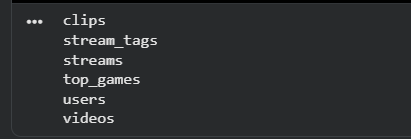

In [ ]:
exclude_tables = {"clips", "videos"}

for table in tables:
    if table.table_id in exclude_tables:
        continue

    table_ref = client.get_table(f"{dataset_id}.{table.table_id}")

    print(f"
Table: {table.table_id}")
    for field in table_ref.schema:
        print(f"  - {field.name} ({field.field_type})")


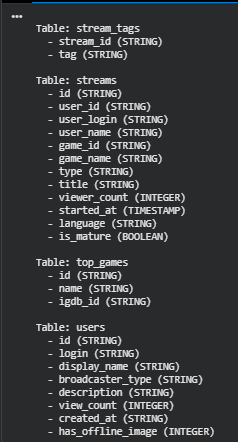


# Data Extraction


The BigQuery Python client returns a pandas DataFrame. Immediately after extraction, it is converted to a Spark DataFrame.

From this point onward, the notebook uses Spark DataFrames for cleaning, feature engineering, preprocessing, and modeling.


In [ ]:
query = """
SELECT *
FROM `TwitchAnalytics.streams`
WHERE game_name = 'Just Chatting'
"""

pandas_df = client.query(query).to_dataframe()

In [5]:
pandas_df = pd.read_csv('/content/my_data_Real.csv')

In [6]:
raw_spark_df = spark.createDataFrame(pandas_df)

print("Rows:", raw_spark_df.count())
print("Columns:", len(raw_spark_df.columns))
raw_spark_df.printSchema()


Rows: 19952
Columns: 12
root
 |-- id: long (nullable = true)
 |-- user_id: long (nullable = true)
 |-- user_login: string (nullable = true)
 |-- user_name: string (nullable = true)
 |-- game_id: long (nullable = true)
 |-- game_name: string (nullable = true)
 |-- type: string (nullable = true)
 |-- title: string (nullable = true)
 |-- viewer_count: long (nullable = true)
 |-- started_at: string (nullable = true)
 |-- language: string (nullable = true)
 |-- is_mature: boolean (nullable = true)




# Data Cleaning

Keep only the columns needed for the time-series prediction task.

`started_at` is converted to timestamp.

`viewer_count` is converted to double because Spark ML models require numeric columns.


In [7]:
streams_df = (
    raw_spark_df
    .select(
        F.to_timestamp(F.col("started_at")).alias("started_at"),
        F.col("viewer_count").cast("double").alias("viewer_count")
    )
    .dropna(subset=["started_at", "viewer_count"])
)

streams_df.show(5, truncate=False)
streams_df.printSchema()


+-------------------+------------+
|started_at         |viewer_count|
+-------------------+------------+
|2026-04-24 20:02:33|1737.0      |
|2026-04-24 20:02:33|1790.0      |
|2026-04-24 20:02:33|1765.0      |
|2026-04-24 20:02:33|2513.0      |
|2026-04-24 20:02:33|2407.0      |
+-------------------+------------+
only showing top 5 rows
root
 |-- started_at: timestamp (nullable = true)
 |-- viewer_count: double (nullable = true)




Time Aggregation

Aggregate total viewers into 5-minute windows.

Doing filtering to remove noise


In [8]:
ts_df = (
    streams_df
    .groupBy(F.window(F.col("started_at"), "5 minutes").alias("time_window"))
    .agg(F.sum("viewer_count").alias("viewer_count"))
    .select(F.col("time_window.start").alias("started_at"), "viewer_count")
    .filter(F.col("viewer_count") > 100)
    .orderBy("started_at")
)

print("Rows after 5-minute aggregation:", ts_df.count())
ts_df.show(10, truncate=False)


Rows after 5-minute aggregation: 611
+-------------------+------------+
|started_at         |viewer_count|
+-------------------+------------+
|2026-04-15 13:40:00|123.0       |
|2026-04-15 14:55:00|418.0       |
|2026-04-15 17:25:00|102.0       |
|2026-04-15 18:25:00|824.0       |
|2026-04-15 22:50:00|104.0       |
|2026-04-16 00:30:00|166.0       |
|2026-04-16 01:00:00|168.0       |
|2026-04-16 02:05:00|120.0       |
|2026-04-16 07:10:00|1110.0      |
|2026-04-16 10:00:00|223.0       |
+-------------------+------------+
only showing top 10 rows



# Feature Engineering

Create lag features, rolling features, time features, smoothing, and the prediction target using Spark window functions.

The target is the smoothed viewer count two 5-minute intervals ahead.


In [10]:
order_window = Window.orderBy("started_at")

feature_df = ts_df

# Lag features: previous 12 intervals = previous 60 minutes when data is in 5-minute windows.
for i in range(1, 13):
    feature_df = feature_df.withColumn(f"lag_{i}", F.lag("viewer_count", i).over(order_window))

# Rolling windows based on previous/current rows.
roll_10min = order_window.rowsBetween(-1, 0)
roll_15min = order_window.rowsBetween(-2, 0)
roll_30min = order_window.rowsBetween(-5, 0)
smooth_window = order_window.rowsBetween(-4, 0)

feature_df = (
    feature_df
    .withColumn("roll_sum_10min", F.sum("viewer_count").over(roll_10min))
    .withColumn("roll_sum_15min", F.sum("viewer_count").over(roll_15min))
    .withColumn("roll_sum_30min", F.sum("viewer_count").over(roll_30min))
    .withColumn("roll_mean_10min", F.avg("viewer_count").over(roll_10min))
    .withColumn("roll_mean_15min", F.avg("viewer_count").over(roll_15min))
    .withColumn("roll_mean_30min", F.avg("viewer_count").over(roll_30min))
    .withColumn("hour", F.hour("started_at"))

    # Spark dayofweek gives 1 = Sunday through 7 = Saturday.
    .withColumn("dayofweek", F.dayofweek("started_at"))
    .withColumn("is_weekend", F.when(F.col("dayofweek").isin(1, 7), F.lit(1)).otherwise(F.lit(0)))

    # .lit() is litteral value
    .withColumn("hour_sin", F.sin(F.lit(2 * math.pi) * F.col("hour") / F.lit(24)))
    .withColumn("hour_cos", F.cos(F.lit(2 * math.pi) * F.col("hour") / F.lit(24)))

    .withColumn("smooth", F.avg("viewer_count").over(smooth_window))
    .withColumn("target", F.lead("smooth", 1).over(order_window))
    .drop("hour")
)

feature_df.show(5, truncate=False)


+-------------------+------------+-----+-----+-----+-----+-----+-----+-----+-----+-----+------+------+------+--------------+--------------+--------------+---------------+------------------+------------------+---------+----------+-------------------+-----------------------+------------------+------------------+
|started_at         |viewer_count|lag_1|lag_2|lag_3|lag_4|lag_5|lag_6|lag_7|lag_8|lag_9|lag_10|lag_11|lag_12|roll_sum_10min|roll_sum_15min|roll_sum_30min|roll_mean_10min|roll_mean_15min   |roll_mean_30min   |dayofweek|is_weekend|hour_sin           |hour_cos               |smooth            |target            |
+-------------------+------------+-----+-----+-----+-----+-----+-----+-----+-----+-----+------+------+------+--------------+--------------+--------------+---------------+------------------+------------------+---------+----------+-------------------+-----------------------+------------------+------------------+
|2026-04-15 13:40:00|123.0       |NULL |NULL |NULL |NULL |NULL |

# Remove Rows Without Complete Features


Lag features and future targets create null values at the start and end of the time series.

Those rows are removed before training.


In [11]:
ml_df = feature_df.dropna()

print("Rows after feature creation and null removal:", ml_df.count())
ml_df.show(5, truncate=False)


Rows after feature creation and null removal: 598
+-------------------+------------+------+------+-----+------+------+------+------+------+-----+------+------+------+--------------+--------------+--------------+---------------+------------------+-----------------+---------+----------+-------------------+--------------------+------+------+
|started_at         |viewer_count|lag_1 |lag_2 |lag_3|lag_4 |lag_5 |lag_6 |lag_7 |lag_8 |lag_9|lag_10|lag_11|lag_12|roll_sum_10min|roll_sum_15min|roll_sum_30min|roll_mean_10min|roll_mean_15min   |roll_mean_30min  |dayofweek|is_weekend|hour_sin           |hour_cos            |smooth|target|
+-------------------+------------+------+------+-----+------+------+------+------+------+-----+------+------+------+--------------+--------------+--------------+---------------+------------------+-----------------+---------+----------+-------------------+--------------------+------+------+
|2026-04-16 13:05:00|189.0       |166.0 |397.0 |223.0|1110.0|120.0 |168.0 |16


# Train/Test Split

The first 80% is used for training and the last 20% is used for testing.


In [12]:
indexed_df = ml_df.withColumn("row_id", F.row_number().over(order_window))
row_count = indexed_df.count()
split_id = int(row_count * 0.8)

train_df = indexed_df.filter(F.col("row_id") <= split_id).drop("row_id")
test_df = indexed_df.filter(F.col("row_id") > split_id).drop("row_id")

print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())


Training rows: 478
Testing rows: 120



# Spark Feature Transformation Pipeline

Spark ML models require one vector column named `features` and one numeric label column.

This pipeline does three preprocessing steps:

1. Combines all input columns into one vector using `VectorAssembler`.
2. Scales the feature vector using `StandardScaler`.


In [13]:
exclude_cols = {"started_at", "viewer_count", "smooth", "target"}

feature_cols = [c for c in train_df.columns if c not in exclude_cols]

print("Feature columns:", feature_cols)

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="unscaled_features",
    handleInvalid="keep"
)

scaler = StandardScaler(
    inputCol="unscaled_features",
    outputCol="features",
    withStd=True,
    withMean=False
)

preprocessing_pipeline = Pipeline(stages=[assembler, scaler])

preprocessing_model = preprocessing_pipeline.fit(train_df)

train_prepared = (
    preprocessing_model
    .transform(train_df)
    .select("started_at", "target", "features")
)

test_prepared = (
    preprocessing_model
    .transform(test_df)
    .select("started_at", "target", "features")
)

train_prepared.show(5, truncate=False)

Feature columns: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'roll_sum_10min', 'roll_sum_15min', 'roll_sum_30min', 'roll_mean_10min', 'roll_mean_15min', 'roll_mean_30min', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos']
+-------------------+------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|started_at         |target|features                                                                                                                                                                                                


# Evaluation Function

Use Spark's `RegressionEvaluator` for MAE, RMSE, and R².


In [14]:
def evaluate_regression(predictions, model_name, num_features=None):
    mae_evaluator = RegressionEvaluator(
        labelCol="target",
        predictionCol="prediction",
        metricName="mae"
    )
    rmse_evaluator = RegressionEvaluator(
        labelCol="target",
        predictionCol="prediction",
        metricName="rmse"
    )
    r2_evaluator = RegressionEvaluator(
        labelCol="target",
        predictionCol="prediction",
        metricName="r2"
    )

    mae = mae_evaluator.evaluate(predictions)
    rmse = rmse_evaluator.evaluate(predictions)
    r2 = r2_evaluator.evaluate(predictions)

    n = predictions.count()

    if num_features is not None and n > num_features + 1:
        adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - num_features - 1))
    else:
        adjusted_r2 = None

    print(f"{model_name} MAE:         {mae}")
    print(f"{model_name} RMSE:        {rmse}")
    print(f"{model_name} R²:          {r2}")

    if adjusted_r2 is not None:
        print(f"{model_name} Adjusted R²: {adjusted_r2}")
    else:
        print(f"{model_name} Adjusted R²: cannot calculate")

    return {
        "model": model_name,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "adjusted_r2": adjusted_r2
    }

============
# Model 1: Spark Random Forest Regressor
============



In [15]:
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="target",
    predictionCol="prediction",
    numTrees=300,
    maxDepth=10,
    seed=42
)

rf_model = rf.fit(train_prepared)
rf_predictions = rf_model.transform(test_prepared)

rf_results = evaluate_regression(rf_predictions, "Spark Random Forest")


Spark Random Forest MAE:         71849.85423789173
Spark Random Forest RMSE:        156749.62835228114
Spark Random Forest R²:          0.6705739071891965
Spark Random Forest Adjusted R²: cannot calculate


============
# Model 2: Spark Gradient-Boosted Trees Regressor
============

This is the Spark ML alternative to gradient boosting models.


In [16]:
gbt = GBTRegressor(
    featuresCol="features",
    labelCol="target",
    predictionCol="prediction",
    maxIter=100,
    maxDepth=6,
    stepSize=0.05,
    seed=42
)

gbt_model = gbt.fit(train_prepared)
gbt_predictions = gbt_model.transform(test_prepared)

gbt_results = evaluate_regression(gbt_predictions, "Spark GBT")


Spark GBT MAE:         76004.87552800594
Spark GBT RMSE:        155001.1489259438
Spark GBT R²:          0.6778821509951111
Spark GBT Adjusted R²: cannot calculate


============
# Model 3: Spark Linear Regression Baseline
============

This gives a simple Spark ML baseline model for comparison.


In [17]:
lr = LinearRegression(
    featuresCol="features",
    labelCol="target",
    predictionCol="prediction",
    maxIter=100,
    regParam=0.1,
    elasticNetParam=0.0
)

lr_model = lr.fit(train_prepared)
lr_predictions = lr_model.transform(test_prepared)

lr_results = evaluate_regression(lr_predictions, "Spark Linear Regression", num_features=len(feature_cols))


Spark Linear Regression MAE:         48844.856001468674
Spark Linear Regression RMSE:        72841.49549332334
Spark Linear Regression R²:          0.9288618342610149
Spark Linear Regression Adjusted R²: 0.9127274049181523


============
# Compare Models
============

Create a Spark DataFrame containing the model scores.


In [20]:
results_df = spark.createDataFrame([rf_results, gbt_results, lr_results])
results_df.orderBy("mae").show(truncate=False)


+------------------+------------------+-----------------------+------------------+------------------+
|adjusted_r2       |mae               |model                  |r2                |rmse              |
+------------------+------------------+-----------------------+------------------+------------------+
|0.9127274049181523|48844.856001468674|Spark Linear Regression|0.9288618342610149|72841.49549332334 |
|NULL              |71849.85423789173 |Spark Random Forest    |0.6705739071891965|156749.62835228114|
|NULL              |76004.87552800594 |Spark GBT              |0.6778821509951111|155001.1489259438 |
+------------------+------------------+-----------------------+------------------+------------------+



The prediction plot converts only the final small prediction result to pandas for visualization.

Training and prediction still happen in Spark.


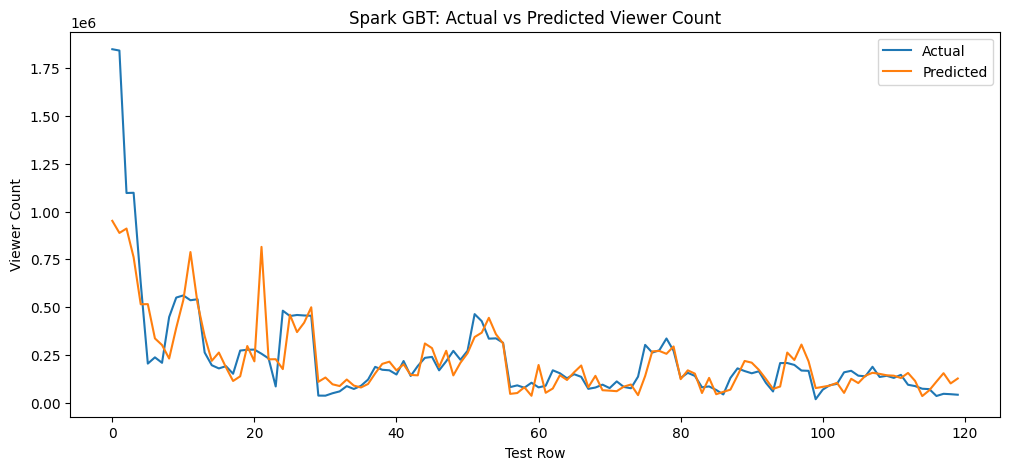

In [23]:
best_predictions = gbt_predictions.select("started_at", "target", "prediction").orderBy("started_at")
plot_pdf = best_predictions.toPandas()

plt.figure(figsize=(12, 5))
plt.plot(plot_pdf["target"].values, label="Actual")
plt.plot(plot_pdf["prediction"].values, label="Predicted")
plt.title("Spark GBT: Actual vs Predicted Viewer Count")
plt.xlabel("Test Row")
plt.ylabel("Viewer Count")
plt.legend()
plt.show()


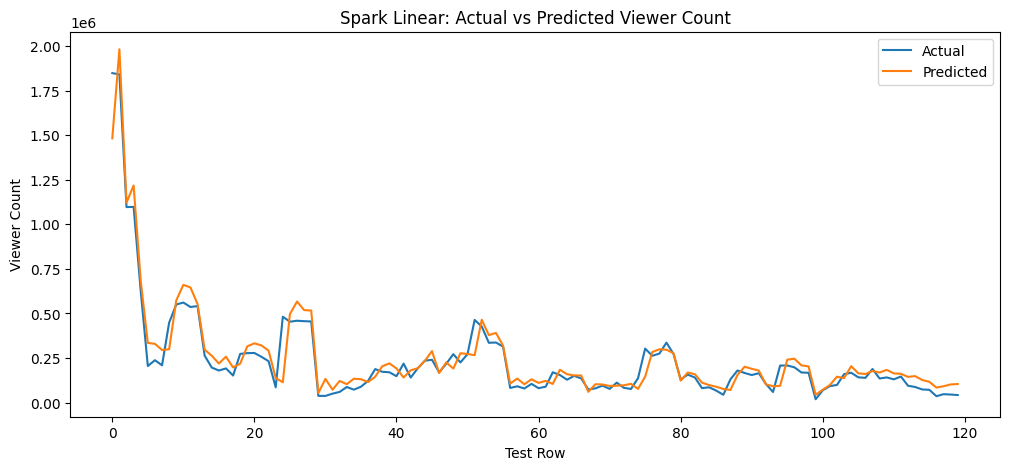

In [25]:
best_predictions = lr_predictions.select("started_at", "target", "prediction").orderBy("started_at")
plot_pdf = best_predictions.toPandas()

plt.figure(figsize=(12, 5))
plt.plot(plot_pdf["target"].values, label="Actual")
plt.plot(plot_pdf["prediction"].values, label="Predicted")
plt.title("Spark Linear: Actual vs Predicted Viewer Count")
plt.xlabel("Test Row")
plt.ylabel("Viewer Count")
plt.legend()
plt.show()